Decoding Transformers Spectra: A Random Matrix Theory Framework Beyond the Marchenko-Pastur Law

# Load BERT and extract original matrices

In [1]:
# extract_bert_matrices.py
from pathlib import Path
import json
import numpy as np
import torch
from transformers import BertModel

def extract_matrices(
    model_name: str = "bert-base-uncased",
    out_dir: str = "bert_weights",
    include_bias: bool = False,
    only_linear_like: bool = True,      # skip LayerNorm/embeddings unless they are 2-D
    dtype: str = "float32",             # "float32" | "float64"
    save_format: str = "npy",           # "npy" | "npz" (np.savez_compressed)
):
    """
    Extracts all weight matrices from a HuggingFace BERT and saves them with a manifest.
    """
    assert save_format in {"npy", "npz"}
    np_dtype = np.float32 if dtype == "float32" else np.float64

    # 1) Load model on CPU, no grad
    torch.set_grad_enabled(False)
    model = BertModel.from_pretrained(model_name)
    model.eval()
    model.to("cpu")

    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)

    # 2) Iterate state_dict for robustness (covers all submodules)
    sd = model.state_dict()
    manifest = {
        "model_name": model_name,
        "dtype": dtype,
        "include_bias": include_bias,
        "only_linear_like": only_linear_like,
        "files": []
    }

    # Helper to filter which tensors to keep
    def keep_param(key: str, tensor: torch.Tensor) -> bool:
        # Want weights (2-D) from linear/attention/FFN; optionally biases (1-D)
        if tensor.ndim == 2:
            # Typically Linear weights, embedding matrices (2-D), etc.
            if only_linear_like:
                # Heuristics: keep common linear/attention/FFN matrices
                names_we_like = (
                    "encoder.layer", "attention", "intermediate", "output.dense",
                    "self.query", "self.key", "self.value", "dense", "pooler.dense"
                )
                return any(n in key for n in names_we_like)
            return True

        if include_bias and tensor.ndim == 1:
            # keep biases if requested
            names_we_like = ("bias",)
            return any(n in key for n in names_we_like)

        return False

    # 3) Save tensors and record metadata
    for key in sorted(sd.keys()):
        t = sd[key]
        if not keep_param(key, t):
            continue

        arr = t.detach().cpu().to(dtype=torch.float32 if dtype == "float32" else torch.float64).numpy()

        # Build a safe, hierarchical path
        # Example key: "encoder.layer.0.attention.self.query.weight"
        # -> encoder/layer_0/attention/self/query/weight.npy
        parts = key.split(".")
        # normalize "layer.N" to "layer_N"
        norm_parts = []
        for p in parts:
            if p == "layer":
                continue
            if p.isdigit():  # the index that follows "layer"
                norm_parts.append(f"layer_{p}")
            else:
                norm_parts.append(p)

        # Put under base directory
        save_dir = out.joinpath(*norm_parts[:-1])  # all but the last (usually "weight" or "bias")
        save_dir.mkdir(parents=True, exist_ok=True)

        stem = norm_parts[-1]  # "weight" or "bias"
        ext = ".npy" if save_format == "npy" else ".npz"
        path = save_dir / f"{stem}{ext}"

        if save_format == "npy":
            np.save(path, arr)
        else:
            np.savez_compressed(path, data=arr)

        manifest["files"].append({
            "name": key,
            "path": str(path.relative_to(out)),
            "shape": list(arr.shape),
            "ndim": arr.ndim,
            "dtype": str(arr.dtype)
        })

    # 4) Also save a flat copy for embeddings if you want them explicitly grouped
    # (Optional—comment out if you don't need a separate embeddings folder)
    emb_dir = out / "embeddings"
    emb_dir.mkdir(exist_ok=True)
    for subkey, param in model.embeddings.state_dict().items():
        if param.ndim == 2 or (include_bias and param.ndim == 1):
            arr = param.detach().cpu().to(dtype=torch.float32 if dtype == "float32" else torch.float64).numpy()
            fname = (subkey.replace(".", "_") + ("_bias" if subkey.endswith("bias") else "") +
                     (".npy" if save_format == "npy" else ".npz"))
            path = emb_dir / fname
            if save_format == "npy":
                np.save(path, arr)
            else:
                np.savez_compressed(path, data=arr)

            manifest["files"].append({
                "name": f"embeddings.{subkey}",
                "path": str(path.relative_to(out)),
                "shape": list(arr.shape),
                "ndim": arr.ndim,
                "dtype": str(arr.dtype)
            })

    # 5) Write manifest
    with open(out / "manifest.json", "w") as f:
        json.dump(manifest, f, indent=2)

    print(f"Saved to: {out.resolve()}")
    print(f"Total tensors saved: {len(manifest['files'])}")

if __name__ == "__main__":
    extract_matrices(
        model_name="bert-base-uncased",
        out_dir="bert_weights",
        include_bias=False,
        only_linear_like=True,
        dtype="float32",
        save_format="npy",
    )

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Saved to: /content/bert_weights
Total tensors saved: 76


# Build Wn and save stats

In [2]:
# =========================
# Build WMP and save stats for inversion
# =========================
# Inputs:
#   - bert_weights/ (from extract_bert_matrices.py)
# Outputs:
#   - step1_column_stats.json   (human-readable, key map)
#   - step1_column_stats.npz    (exact np arrays of means/stds)
#   - bert_weights_WMP/          (normalized matrices) + manifest.json

import json
import re
from datetime import datetime, UTC
from pathlib import Path
import numpy as np

WEIGHTS_DIR = "bert_weights"
STATS_JSON  = "step1_column_stats.json"
STATS_NPZ   = "step1_column_stats.npz"
WMP_DIR      = "bert_weights_WMP"

def _safe_key(idx: int, kind: str, name: str) -> str:
    """Create stable NPZ keys like '0003__mean__encoder_layer_0_attention_self_query_weight'."""
    base = f"{idx:04d}__{kind}__" + re.sub(r"[^0-9a-zA-Z_]+", "_", name)
    base = re.sub(r"__+", "__", base).strip("_")
    return base[:200]

def _load_matrix(path: Path) -> np.ndarray:
    if path.suffix == ".npy":
        return np.load(path)
    if path.suffix == ".npz":
        return np.load(path)["data"]
    raise ValueError(f"Unsupported file type: {path.suffix}")

def _save_npy(path: Path, arr: np.ndarray) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    np.save(path, arr)

# ------------- Step 1: compute and save column-wise stats -------------
weights_dir = Path(WEIGHTS_DIR)
manifest_path = weights_dir / "manifest.json"
assert manifest_path.exists(), f"Manifest not found at {manifest_path}"

with open(manifest_path, "r") as f:
    manifest = json.load(f)

npz_store = {}
stats_json = {
    "model_name": manifest.get("model_name", ""),
    "created_at": datetime.now(UTC).isoformat(),
    "weights_dir": str(weights_dir),
    "count_files": 0,
    "files": []
}

files = manifest.get("files", [])
processed = 0
for idx, entry in enumerate(files):
    relpath = entry.get("path")
    name    = entry.get("name", relpath)
    shape   = entry.get("shape")

    fpath = weights_dir / relpath
    if not fpath.exists():
        print(f"[MISS] {relpath}")
        continue

    try:
        W = _load_matrix(fpath)
    except Exception as e:
        print(f"[LOAD-ERR] {relpath}: {e}")
        continue

    if W.ndim != 2:
        continue  # only 2-D matrices

    # Column-wise stats (axis=0); compute in float64 for stability
    W = W.astype(np.float64, copy=False)
    mu = W.mean(axis=0)          # shape (n,)
    sd = W.std(axis=0)           # shape (n,)

    mean_key = _safe_key(idx, "mean", name)
    std_key  = _safe_key(idx, "std",  name)
    npz_store[mean_key] = mu
    npz_store[std_key]  = sd

    stats_json["files"].append({
        "index": idx,
        "name": name,
        "path": relpath,
        "shape": shape,
        "npz_keys": {"mean": mean_key, "std": std_key},
        "summary": {
            "mean_of_means": float(mu.mean()),
            "mean_of_stds": float(sd.mean()),
            "max_std": float(sd.max()),
            "min_std": float(sd.min())
        }
    })
    processed += 1
    if processed % 25 == 0:
        print(f"[STATS] Processed {processed} matrices...")

stats_json["count_files"] = processed

with open(STATS_JSON, "w") as jf:
    json.dump(stats_json, jf, indent=2)
np.savez_compressed(STATS_NPZ, **npz_store)

print(f"[STATS] Done. Matrices processed: {processed}")
print(f"[STATS] JSON: {STATS_JSON}")
print(f"[STATS] NPZ : {STATS_NPZ}")

# ------------- Step 2: build WMP=(W - 1*mu)/sd and save with manifest -------------
out_root = Path(WMP_DIR)
out_root.mkdir(parents=True, exist_ok=True)

# prepare WMP manifest (clone key fields)
wmp_manifest = {
    "model_name": manifest.get("model_name", "") + " (column-standardized)",
    "dtype": "float64",
    "include_bias": manifest.get("include_bias", False),
    "only_linear_like": manifest.get("only_linear_like", True),
    "files": []
}

stats_npz = np.load(STATS_NPZ)

saved = 0
skipped = 0
for entry in stats_json["files"]:
    relpath = entry["path"]
    name    = entry["name"]
    mu      = stats_npz[entry["npz_keys"]["mean"]]  # (n,)
    sd      = stats_npz[entry["npz_keys"]["std"]]   # (n,)

    src_path = weights_dir / relpath
    if not src_path.exists():
        print(f"[MISS-WMP] {relpath}")
        continue

    W = _load_matrix(src_path)
    if W.ndim != 2:
        skipped += 1
        continue

    W = W.astype(np.float64, copy=False)

    # Guard zero-variance columns; they remain constant after normalization
    safe_sd = np.where(sd == 0, 1.0, sd)

    # WMP = (W - 1*mu)/sd  -> broadcast along rows (axis=0)
    WMP = (W - mu.reshape(1, -1)) / safe_sd.reshape(1, -1)

    dst_path = out_root / relpath
    _save_npy(dst_path, WMP)

    wmp_manifest["files"].append({
        "name": name.replace(".weight", ".weight_WMP"),
        "path": str(dst_path.relative_to(out_root)),
        "shape": list(WMP.shape),
        "ndim": 2,
        "dtype": str(WMP.dtype)
    })
    saved += 1
    if saved % 25 == 0:
        print(f"[WMP] Saved {saved} matrices...")

with open(out_root / "manifest.json", "w") as f:
    json.dump(wmp_manifest, f, indent=2)

# ------------- Quick verification on a few matrices -------------
from itertools import islice

def _check_one(relpath: str, mu: np.ndarray, sd: np.ndarray) -> float:
    W  = _load_matrix(weights_dir / relpath).astype(np.float64)
    WMP = _load_matrix(out_root / relpath).astype(np.float64)
    safe_sd = np.where(sd == 0, 1.0, sd)
    W_rec = WMP * safe_sd.reshape(1, -1) + mu.reshape(1, -1)
    return float(np.max(np.abs(W - W_rec)))

print("====================================================")
print(f"✅ WMP saved: {saved} | Skipped (non-2D): {skipped}")
print(f"Manifest written: {out_root / 'manifest.json'}")

# Pick up to 3 entries and verify round-trip reconstruction
errs = []
for e in islice(stats_json["files"], 3):
    rel = e["path"]
    mu  = stats_npz[e["npz_keys"]["mean"]]
    sd  = stats_npz[e["npz_keys"]["std"]]
    errs.append((rel, _check_one(rel, mu, sd)))
for rel, err in errs:
    print(f"[CHECK] {rel}: max |W - (WMP*sd+mu)| = {err:.3e}")
print("====================================================")


[STATS] Processed 25 matrices...
[STATS] Processed 50 matrices...
[STATS] Processed 75 matrices...
[STATS] Done. Matrices processed: 76
[STATS] JSON: step1_column_stats.json
[STATS] NPZ : step1_column_stats.npz
[WMP] Saved 25 matrices...
[WMP] Saved 50 matrices...
[WMP] Saved 75 matrices...
✅ WMP saved: 76 | Skipped (non-2D): 0
Manifest written: bert_weights_WMP/manifest.json
[CHECK] encoder/layer_0/attention/output/dense/weight.npy: max |W - (WMP*sd+mu)| = 2.776e-17
[CHECK] encoder/layer_0/attention/self/key/weight.npy: max |W - (WMP*sd+mu)| = 1.110e-16
[CHECK] encoder/layer_0/attention/self/query/weight.npy: max |W - (WMP*sd+mu)| = 5.551e-17


# Graph 1 - Empirical PDF (ePDF) vs. conditional MPd PDF under different trimming conditions.

Building mosaic figure...
  [1/6] Set 1 — L0 FFN
         shape=(3.07e+03 x 7.68e+02), dtype=float64
         beta=2.5000e-01 | support=[2.5000e-01, 2.2500e+00]
         trim=[3.5000e-01, 2.1500e+00] | N_trim=5.95e+02
  [2/6] Set 2 — L0 Att.Q
         shape=(7.68e+02 x 7.68e+02), dtype=float64
         beta=2.5000e-01 | support=[2.5000e-01, 2.2500e+00]
         trim=[3.5000e-01, 2.1500e+00] | N_trim=2.75e+02
  [3/6] Set 3 — L5 Att.K
         shape=(7.68e+02 x 7.68e+02), dtype=float64
         beta=2.5000e-01 | support=[2.5000e-01, 2.2500e+00]
         trim=[3.5000e-01, 2.1500e+00] | N_trim=3.01e+02
  [4/6] Set 4 — L5 Out
         shape=(7.68e+02 x 3.07e+03), dtype=float64
         beta=1.0000e+00 | support=[0.0000e+00, 4.0000e+00]
         trim=[2.0000e-01, 3.8000e+00] | N_trim=7.39e+02
  [5/6] Set 5 — L11 FFN
         shape=(3.07e+03 x 7.68e+02), dtype=float64
         beta=1.0000e+00 | support=[0.0000e+00, 4.0000e+00]
         trim=[2.0000e-01, 3.8000e+00] | N_trim=7.31e+02
  [6/6] S

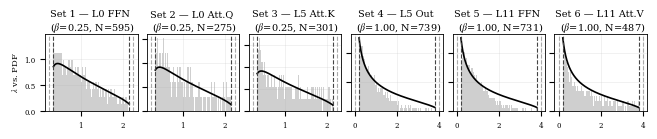

Done.


In [3]:
# ============================================================
# Graph 1 — Empirical PDF vs. conditional MPd PDF
# ============================================================

import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "legend.fontsize": 5,
    "axes.linewidth": 0.6,
    "lines.linewidth": 1.2,
    "grid.linewidth": 0.4,
    "grid.alpha": 0.3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def _load_matrix(p: Path):
    if p.suffix == ".npy":  return np.load(p)
    if p.suffix == ".npz":  return np.load(p)["data"]
    raise ValueError(f"Unsupported file type: {p.suffix}")

def _mp_support(beta: float):
    r = np.sqrt(beta); return (1 - r)**2, (1 + r)**2

def _mp_pdf(x, beta, a, b):
    x = np.asarray(x, dtype=np.float64)
    out = np.zeros_like(x)
    m = (x >= a) & (x <= b)
    xm = np.clip(x[m], 1e-15, None)
    out[m] = np.sqrt((b - xm) * (xm - a)) / (2 * np.pi * beta * xm)
    return out

def _cumtrapz_np(y, x):
    dx = np.diff(x); seg = 0.5 * (y[:-1] + y[1:]) * dx
    return np.concatenate([[0.0], np.cumsum(seg)])

def _mp_cdf(x, beta, grid_points=8192):
    a, b = _mp_support(beta)
    t = np.linspace(0.0, 1.0, grid_points)
    g = a + (b - a) * t * t
    pdf = _mp_pdf(g, beta, a, b)
    cdf_vals = _cumtrapz_np(pdf, g)
    cdf_vals /= cdf_vals[-1]
    return np.interp(x, g, cdf_vals, left=0.0, right=1.0)

def _edge_margin(beta, m, n, trim_kind, c_tw, frac_sq, frac_rect):
    a, b = _mp_support(beta); bandwidth = b - a
    n_eff = min(m, n); is_square = (m == n)
    tw = c_tw * (n_eff ** (-2/3)) * (1 + np.sqrt(beta))**(4/3)
    frac = (frac_sq if is_square else frac_rect) * bandwidth
    if trim_kind == "tw": return tw
    if trim_kind == "fraction": return frac
    if trim_kind == "tw_or_fraction": return max(tw, frac)
    raise ValueError("Invalid trim_kind")

def _find_manifest_entry(manifest, target):
    for e in manifest["files"]:
        if e.get("name","") == target: return e
    for e in manifest["files"]:
        if target in e.get("name","") or target in e.get("path",""): return e
    raise ValueError(f"Matrix '{target}' not found in manifest")

def compute_trimmed(W, TRIM_KIND, C_TW, EDGE_FRAC_SQUARE, EDGE_FRAC_RECT, beta_override=None):
    m, n = W.shape
    beta = beta_override if beta_override is not None else min(m, n) / max(m, n)
    s = np.linalg.svd(W, full_matrices=False, compute_uv=False)
    lambdas = (s**2) / max(m, n); lambdas.sort()
    a, b = _mp_support(beta)
    delta = _edge_margin(beta, m, n, TRIM_KIND, C_TW, EDGE_FRAC_SQUARE, EDGE_FRAC_RECT)
    L, U = a + delta, b - delta
    if L >= U: L, U = a, b
    mask = (lambdas >= L) & (lambdas <= U)
    lam_trim = lambdas[mask]; N_trim = lam_trim.size
    FL, FU = _mp_cdf([L, U], beta); den = max(FU - FL, 1e-12)
    mp_pdf_cond = lambda x: _mp_pdf(x, beta, a, b) / den
    mp_cdf_cond = lambda x: np.clip((_mp_cdf(x, beta) - FL) / den, 0, 1)
    return lam_trim, (a, b, L, U, beta), mp_pdf_cond, mp_cdf_cond, N_trim

# Config
WMP_DIR   = "bert_weights_WMP"
COND_GRID = 2000
HIST_BINS = 150

# BERT-base: 12 layers, hidden=768, intermediate=3072
# Sets 1-3: beta_override=0.25 | Sets 4-6: beta_override=1.00
SETTINGS = [
    dict(name="encoder.layer.0.intermediate.dense.weight_WMP",
         trim_kind="tw_or_fraction", c_tw=2.0, frac_sq=0.05, frac_rect=0.05,
         beta_override=0.25, label="Set 1 — L0 FFN"),
    dict(name="encoder.layer.0.attention.self.query.weight_WMP",
         trim_kind="tw_or_fraction", c_tw=2.0, frac_sq=0.05, frac_rect=0.05,
         beta_override=0.25, label="Set 2 — L0 Att.Q"),
    dict(name="encoder.layer.5.attention.self.key.weight_WMP",
         trim_kind="tw_or_fraction", c_tw=2.0, frac_sq=0.05, frac_rect=0.05,
         beta_override=0.25, label="Set 3 — L5 Att.K"),
    dict(name="encoder.layer.5.output.dense.weight_WMP",
         trim_kind="tw_or_fraction", c_tw=2.0, frac_sq=0.05, frac_rect=0.05,
         beta_override=1.00, label="Set 4 — L5 Out"),
    dict(name="encoder.layer.11.intermediate.dense.weight_WMP",
         trim_kind="tw_or_fraction", c_tw=2.0, frac_sq=0.05, frac_rect=0.05,
         beta_override=1.00, label="Set 5 — L11 FFN"),
    dict(name="encoder.layer.11.attention.self.value.weight_WMP",
         trim_kind="tw_or_fraction", c_tw=2.0, frac_sq=0.05, frac_rect=0.05,
         beta_override=1.00, label="Set 6 — L11 Att.V"),
]

man_path = Path(WMP_DIR) / "manifest.json"
manifest = json.load(open(man_path))

print("Building mosaic figure...")

fig, axes = plt.subplots(1, 6, figsize=(7, 1))
axes = axes.flatten()

for i, (ax, cfg) in enumerate(zip(axes, SETTINGS)):
    print(f"  [{i+1}/6] {cfg['label']}")
    entry = _find_manifest_entry(manifest, cfg["name"])
    W = _load_matrix(Path(WMP_DIR) / entry["path"]).astype(np.float64, copy=False)
    print(f"         shape=({W.shape[0]:.2e} x {W.shape[1]:.2e}), dtype={W.dtype}")

    lam_trim, (a, b, L, U, beta), mp_pdf_cond, _, N_trim = compute_trimmed(
        W, cfg["trim_kind"], cfg["c_tw"], cfg["frac_sq"], cfg["frac_rect"],
        beta_override=cfg.get("beta_override", None)
    )
    print(f"         beta={beta:.4e} | support=[{a:.4e}, {b:.4e}]")
    print(f"         trim=[{L:.4e}, {U:.4e}] | N_trim={N_trim:.2e}")

    x_grid = np.linspace(L, U, COND_GRID)

    if N_trim > 0:
        ax.hist(lam_trim, bins=HIST_BINS, range=(L, U),
                density=True, alpha=0.4, color="#888888")
    ax.plot(x_grid, mp_pdf_cond(x_grid), color="black")

    for v, col in [(a,"#aaaaaa"),(b,"#aaaaaa"),(L,"#444444"),(U,"#444444")]:
        ax.axvline(v, color=col, linestyle="--", linewidth=0.8)

    ax.set_title(f"{cfg['label']} \n ($\\beta$={beta:.2f}, N={N_trim})", pad=2)
    ax.grid(True)

    if i != 0:
        ax.yaxis.set_ticklabels([])

fig.text(-0.01, 0.5, "$\\lambda$ vs. PDF", va="center", rotation="vertical", fontsize=6)
plt.subplots_adjust(left=0.04, hspace=0.0, wspace=0.1)

pdf_path = "graph_core_diag_01_bert_base.pdf"
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
print(f"PDF saved: {pdf_path}")
plt.show()
plt.close()
print("Done.")

# Graph 2 - Empirical CDF (eCDF) vs. conditional MPd CDF under different trimming conditions.

Building mosaic figure...
  [1/6] Set 1 — L0 FFN
         shape=(3.07e+03 x 7.68e+02), dtype=float64
         beta=2.5000e-01 | support=[2.5000e-01, 2.2500e+00]
         trim=[3.5000e-01, 2.1500e+00] | N_trim=5.95e+02
  [2/6] Set 2 — L0 Att.Q
         shape=(7.68e+02 x 7.68e+02), dtype=float64
         beta=2.5000e-01 | support=[2.5000e-01, 2.2500e+00]
         trim=[3.5000e-01, 2.1500e+00] | N_trim=2.75e+02
  [3/6] Set 3 — L5 Att.K
         shape=(7.68e+02 x 7.68e+02), dtype=float64
         beta=2.5000e-01 | support=[2.5000e-01, 2.2500e+00]
         trim=[3.5000e-01, 2.1500e+00] | N_trim=3.01e+02
  [4/6] Set 4 — L5 Out
         shape=(7.68e+02 x 3.07e+03), dtype=float64
         beta=1.0000e+00 | support=[0.0000e+00, 4.0000e+00]
         trim=[2.0000e-01, 3.8000e+00] | N_trim=7.39e+02
  [5/6] Set 5 — L11 FFN
         shape=(3.07e+03 x 7.68e+02), dtype=float64
         beta=1.0000e+00 | support=[0.0000e+00, 4.0000e+00]
         trim=[2.0000e-01, 3.8000e+00] | N_trim=7.31e+02
  [6/6] S

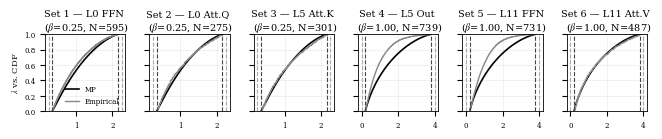

Done.


In [4]:
# ============================================================
# Graph 2 — Empirical CDF vs. conditional MPd CDF
# ============================================================

from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 5,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "legend.fontsize": 5,
    "axes.linewidth": 0.6,
    "lines.linewidth": 1.2,
    "grid.linewidth": 0.4,
    "grid.alpha": 0.3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

print("Building mosaic figure...")

fig, axes = plt.subplots(1, 6, figsize=(7, 1))
axes = axes.flatten()

for i, (ax, cfg) in enumerate(zip(axes, SETTINGS)):
    print(f"  [{i+1}/6] {cfg['label']}")
    entry = _find_manifest_entry(manifest, cfg["name"])
    W = _load_matrix(Path(WMP_DIR) / entry["path"]).astype(np.float64, copy=False)
    print(f"         shape=({W.shape[0]:.2e} x {W.shape[1]:.2e}), dtype={W.dtype}")

    lam_trim, (a, b, L, U, beta), _, mp_cdf_cond, N_trim = compute_trimmed(
        W, cfg["trim_kind"], cfg["c_tw"], cfg["frac_sq"], cfg["frac_rect"],
        beta_override=cfg.get("beta_override", None)
    )
    print(f"         beta={beta:.4e} | support=[{a:.4e}, {b:.4e}]")
    print(f"         trim=[{L:.4e}, {U:.4e}] | N_trim={N_trim:.2e}")

    x_grid = np.linspace(L, U, COND_GRID)
    ax.plot(x_grid, mp_cdf_cond(x_grid), color="black")

    if N_trim > 0:
        y_ecdf = np.arange(1, N_trim + 1) / N_trim
        ax.step(lam_trim, y_ecdf, where="post", linewidth=1.0, color="#888888")

    for v, col in [(a,"#aaaaaa"),(b,"#aaaaaa"),(L,"#444444"),(U,"#444444")]:
        ax.axvline(v, color=col, linestyle="--", linewidth=0.8)

    ax.set_title(f"{cfg['label']} \n ($\\beta$={beta:.2f}, N={N_trim})", pad=2)
    ax.set_ylim(0, 1)
    ax.grid(True)

    if i != 0:
        ax.yaxis.set_ticklabels([])

handles = [
    Line2D([0], [0], color="black", linewidth=1.2, label="MP"),
    Line2D([0], [0], color="#888888", linewidth=1.0, drawstyle="steps-post", label="Empirical"),
]
axes[0].legend(handles=handles, loc="lower right", frameon=False)
fig.text(-0.01, 0.5, "$\\lambda$ vs. CDF", va="center", rotation="vertical", fontsize=6)
plt.subplots_adjust(left=0.04, hspace=0.0, wspace=0.3)

pdf_path = "graph_core_diag_02_bert_base.pdf"
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
print(f"PDF saved: {pdf_path}")
plt.show()
plt.close()
print("Done.")

# Graph 3 - Empirical PDF (ePDF) vs. conditional MPd PDF across selected layers and matrix types.



Building mosaic figure...
  [1/6] Set 1 — L0 FFN
         shape=(3.07e+03 x 7.68e+02), dtype=float64
         beta=2.5000e-01 | support=[2.5000e-01, 2.2500e+00]
         trim=[3.5000e-01, 2.1500e+00] | N_trim=5.95e+02
  [2/6] Set 2 — L0 Att.Q
         shape=(7.68e+02 x 7.68e+02), dtype=float64
         beta=2.5000e-01 | support=[2.5000e-01, 2.2500e+00]
         trim=[3.5000e-01, 2.1500e+00] | N_trim=2.75e+02
  [3/6] Set 3 — L5 Att.K
         shape=(7.68e+02 x 7.68e+02), dtype=float64
         beta=2.5000e-01 | support=[2.5000e-01, 2.2500e+00]
         trim=[3.5000e-01, 2.1500e+00] | N_trim=3.01e+02
  [4/6] Set 4 — L5 Out
         shape=(7.68e+02 x 3.07e+03), dtype=float64
         beta=1.0000e+00 | support=[0.0000e+00, 4.0000e+00]
         trim=[2.0000e-01, 3.8000e+00] | N_trim=7.39e+02
  [5/6] Set 5 — L11 FFN
         shape=(3.07e+03 x 7.68e+02), dtype=float64
         beta=1.0000e+00 | support=[0.0000e+00, 4.0000e+00]
         trim=[2.0000e-01, 3.8000e+00] | N_trim=7.31e+02
  [6/6] S

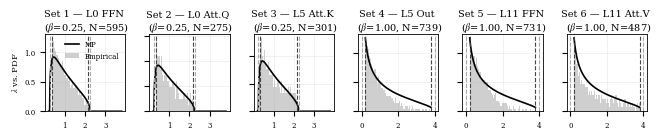

Done.


In [5]:
# ============================================================
# Graph 3 — Empirical density vs MP pdf (trimmed interior, global axes)
# ============================================================

from matplotlib.patches import Patch

COND_GRID   = 2000
HIST_BINS   = 120
GRID_POINTS = 8192

print("Building mosaic figure...")

# First pass: compute global [L, U]
global_L, global_U = np.inf, -np.inf
for cfg in SETTINGS:
    entry = _find_manifest_entry(manifest, cfg["name"])
    W = _load_matrix(Path(WMP_DIR) / entry["path"]).astype(np.float64, copy=False)
    beta = cfg.get("beta_override") or min(W.shape) / max(W.shape)
    a, b = _mp_support(beta)
    delta = _edge_margin(beta, W.shape[0], W.shape[1],
                         cfg["trim_kind"], cfg["c_tw"], cfg["frac_sq"], cfg["frac_rect"])
    L, U = a + delta, b - delta
    if L >= U: L, U = a, b
    global_L, global_U = min(global_L, L), max(global_U, U)

fig, axes = plt.subplots(1, 6, figsize=(7, 1))
axes = axes.flatten()

for i, (ax, cfg) in enumerate(zip(axes, SETTINGS)):
    print(f"  [{i+1}/6] {cfg['label']}")
    entry = _find_manifest_entry(manifest, cfg["name"])
    W = _load_matrix(Path(WMP_DIR) / entry["path"]).astype(np.float64, copy=False)
    print(f"         shape=({W.shape[0]:.2e} x {W.shape[1]:.2e}), dtype={W.dtype}")

    lam_trim, (a, b, L, U, beta), mp_pdf_cond, _, N_trim = compute_trimmed(
        W, cfg["trim_kind"], cfg["c_tw"], cfg["frac_sq"], cfg["frac_rect"],
        beta_override=cfg.get("beta_override", None)
    )
    print(f"         beta={beta:.4e} | support=[{a:.4e}, {b:.4e}]")
    print(f"         trim=[{L:.4e}, {U:.4e}] | N_trim={N_trim:.2e}")

    x_grid = np.linspace(global_L, global_U, COND_GRID)

    if N_trim > 0:
        ax.hist(lam_trim, bins=HIST_BINS, range=(global_L, global_U),
                density=True, alpha=0.4, color="#888888")
    ax.plot(x_grid, mp_pdf_cond(x_grid), color="black")

    for v, col in [(a,"#aaaaaa"),(b,"#aaaaaa"),(L,"#444444"),(U,"#444444")]:
        ax.axvline(v, color=col, linestyle="--", linewidth=0.8)

    ax.set_title(f"{cfg['label']} \n ($\\beta$={beta:.2f}, N={N_trim})", pad=2)
    ax.grid(True)

    if i != 0:
        ax.yaxis.set_ticklabels([])

handles = [
    Line2D([0], [0], color="black", linewidth=1.2, label="MP"),
    Patch(facecolor="#888888", alpha=0.4, label="Empirical"),
]
axes[0].legend(handles=handles, loc="upper right", frameon=False)
fig.text(-0.01, 0.5, "$\\lambda$ vs. PDF", va="center", rotation="vertical", fontsize=6)
plt.subplots_adjust(left=0.04, hspace=0.0, wspace=0.3)

pdf_path = "graph_core_diag_03_bert_base.pdf"
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
print(f"PDF saved: {pdf_path}")
plt.show()
plt.close()
print("Done.")

# Graph 4 - Empirical residual CDF (eCDF–MPd CDF) across different trimming conditions.

Building mosaic figure...
  [1/6] Set 1 — L0 FFN
         shape=(3.07e+03 x 7.68e+02), dtype=float64
         beta=2.5000e-01 | support=[2.5000e-01, 2.2500e+00]
         trim=[3.5000e-01, 2.1500e+00] | N_trim=5.95e+02
  [2/6] Set 2 — L0 Att.Q
         shape=(7.68e+02 x 7.68e+02), dtype=float64
         beta=2.5000e-01 | support=[2.5000e-01, 2.2500e+00]
         trim=[3.5000e-01, 2.1500e+00] | N_trim=2.75e+02
  [3/6] Set 3 — L5 Att.K
         shape=(7.68e+02 x 7.68e+02), dtype=float64
         beta=2.5000e-01 | support=[2.5000e-01, 2.2500e+00]
         trim=[3.5000e-01, 2.1500e+00] | N_trim=3.01e+02
  [4/6] Set 4 — L5 Out
         shape=(7.68e+02 x 3.07e+03), dtype=float64
         beta=1.0000e+00 | support=[0.0000e+00, 4.0000e+00]
         trim=[2.0000e-01, 3.8000e+00] | N_trim=7.39e+02
  [5/6] Set 5 — L11 FFN
         shape=(3.07e+03 x 7.68e+02), dtype=float64
         beta=1.0000e+00 | support=[0.0000e+00, 4.0000e+00]
         trim=[2.0000e-01, 3.8000e+00] | N_trim=7.31e+02
  [6/6] S

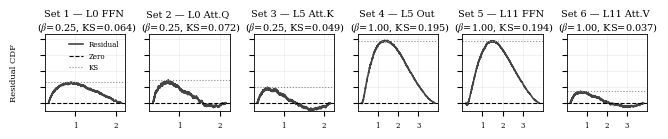

Done.


In [6]:
# --- Graph #4: Residual CDF plots for 6 parameter sets ---
# Model: BERT-base-uncased

import re
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =========================
# GLOBAL STYLE (Paper)
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 5,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "legend.fontsize": 5,
    "axes.linewidth": 0.6,
    "lines.linewidth": 1.2,
    "grid.linewidth": 0.4,
    "grid.alpha": 0.3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================
# Config
# =========================
WMP_DIR     = "bert_weights_WMP"
GRID_POINTS = 8192
COND_GRID   = 2000

# Sets 1-3: beta fixed at 0.25
# Sets 4-6: beta fixed at 1.00
SETTINGS = [
    dict(name="encoder.layer.0.intermediate.dense.weight_WMP",
         trim_kind="tw_or_fraction", c_tw=2.0, frac_sq=0.05, frac_rect=0.05,
         beta_override=0.25, label="Set 1 — L0 FFN"),
    dict(name="encoder.layer.0.attention.self.query.weight_WMP",
         trim_kind="tw_or_fraction", c_tw=2.0, frac_sq=0.05, frac_rect=0.05,
         beta_override=0.25, label="Set 2 — L0 Att.Q"),
    dict(name="encoder.layer.5.attention.self.key.weight_WMP",
         trim_kind="tw_or_fraction", c_tw=2.0, frac_sq=0.05, frac_rect=0.05,
         beta_override=0.25, label="Set 3 — L5 Att.K"),
    dict(name="encoder.layer.5.output.dense.weight_WMP",
         trim_kind="tw_or_fraction", c_tw=2.0, frac_sq=0.05, frac_rect=0.05,
         beta_override=1.00, label="Set 4 — L5 Out"),
    dict(name="encoder.layer.11.intermediate.dense.weight_WMP",
         trim_kind="tw_or_fraction", c_tw=2.0, frac_sq=0.05, frac_rect=0.05,
         beta_override=1.00, label="Set 5 — L11 FFN"),
    dict(name="encoder.layer.11.attention.self.value.weight_WMP",
         trim_kind="tw_or_fraction", c_tw=2.0, frac_sq=0.05, frac_rect=0.05,
         beta_override=1.00, label="Set 6 — L11 Att.V"),
]

# =========================
# Helpers
# =========================
def _load_matrix(p: Path):
    if p.suffix == ".npy":  return np.load(p)
    if p.suffix == ".npz":  return np.load(p)["data"]
    raise ValueError(f"Unsupported file type: {p.suffix}")

def _mp_support(beta: float):
    r = np.sqrt(beta); return (1 - r)**2, (1 + r)**2

def _mp_pdf(x, beta, a, b):
    x = np.asarray(x, dtype=np.float64)
    out = np.zeros_like(x)
    m = (x >= a) & (x <= b)
    xm = np.clip(x[m], 1e-15, None)
    out[m] = np.sqrt((b - xm) * (xm - a)) / (2 * np.pi * beta * xm)
    return out

def _cumtrapz_np(y, x):
    dx = np.diff(x); seg = 0.5 * (y[:-1] + y[1:]) * dx
    return np.concatenate([[0.0], np.cumsum(seg)])

def _mp_cdf(x, beta, grid_points=GRID_POINTS):
    a, b = _mp_support(beta)
    t = np.linspace(0.0, 1.0, grid_points)
    g = a + (b - a) * t * t
    pdf = _mp_pdf(g, beta, a, b)
    cdf_vals = _cumtrapz_np(pdf, g)
    cdf_vals /= cdf_vals[-1]
    return np.interp(x, g, cdf_vals, left=0.0, right=1.0)

def _edge_margin(beta, m, n, trim_kind, c_tw, frac_sq, frac_rect):
    a, b = _mp_support(beta); bandwidth = b - a
    n_eff = min(m, n); is_square = (m == n)
    tw = (c_tw or 0) * (n_eff ** (-2/3)) * (1 + np.sqrt(beta))**(4/3)
    frac = (frac_sq if is_square else frac_rect) * bandwidth
    if trim_kind == "tw":             return tw
    if trim_kind == "fraction":       return frac
    if trim_kind == "tw_or_fraction": return max(tw, frac)
    raise ValueError("Invalid trim_kind")

def _find_manifest_entry(manifest, target):
    for e in manifest["files"]:
        if e.get("name","") == target: return e
    for e in manifest["files"]:
        if target in e.get("name","") or target in e.get("path",""): return e
    raise ValueError(f"Matrix '{target}' not found in manifest")

def compute_trimmed(W, TRIM_KIND, C_TW, EDGE_FRAC_SQUARE, EDGE_FRAC_RECT, beta_override=None):
    m, n = W.shape
    beta = beta_override if beta_override is not None else min(m, n) / max(m, n)
    s = np.linalg.svd(W, full_matrices=False, compute_uv=False)
    lambdas = (s**2) / max(m, n); lambdas.sort()
    a, b = _mp_support(beta)
    delta = _edge_margin(beta, m, n, TRIM_KIND, C_TW, EDGE_FRAC_SQUARE, EDGE_FRAC_RECT)
    L, U = a + delta, b - delta
    if L >= U: L, U = a, b
    mask = (lambdas >= L) & (lambdas <= U)
    lam_trim = lambdas[mask]; N_trim = lam_trim.size
    FL, FU = _mp_cdf([L, U], beta); den = max(FU - FL, 1e-12)
    mp_cdf_cond = lambda x: np.clip((_mp_cdf(x, beta) - FL) / den, 0, 1)
    return lam_trim, (a, b, L, U, beta), mp_cdf_cond, N_trim

# =========================
# Load manifest
# =========================
man_path = Path(WMP_DIR) / "manifest.json"
manifest = json.load(open(man_path))

# =========================
# MOSAIC: Residual CDFs — 1x6 grid
# =========================
print("Building mosaic figure...")

fig, axes = plt.subplots(1, 6, figsize=(7, 1), sharey=True)
axes = axes.flatten()

y_min, y_max = 0, 0

for i, (ax, cfg) in enumerate(zip(axes, SETTINGS)):
    print(f"  [{i+1}/6] {cfg['label']}")

    entry = _find_manifest_entry(manifest, cfg["name"])
    W = _load_matrix(Path(WMP_DIR) / entry["path"]).astype(np.float64, copy=False)
    print(f"         shape=({W.shape[0]:.2e} x {W.shape[1]:.2e}), dtype={W.dtype}")

    lam_trim, (a, b, L, U, beta), mp_cdf_cond, N_trim = compute_trimmed(
        W, cfg["trim_kind"], cfg["c_tw"], cfg["frac_sq"], cfg["frac_rect"],
        beta_override=cfg.get("beta_override", None)
    )
    print(f"         beta={beta:.4e} | support=[{a:.4e}, {b:.4e}]")
    print(f"         trim=[{L:.4e}, {U:.4e}] | N_trim={N_trim:.2e}")

    x_grid  = np.linspace(L, U, COND_GRID)
    emp_cdf = np.searchsorted(np.sort(lam_trim), x_grid, side="right") / max(N_trim, 1)
    residual = emp_cdf - mp_cdf_cond(x_grid)
    ks_stat  = np.max(np.abs(residual))

    ax.plot(x_grid, residual, color="#444444", lw=1.2)
    ax.axhline(0,        color="black",   linestyle="--", linewidth=0.8)
    ax.axhline(+ks_stat, color="#888888", linestyle=":",  linewidth=0.8)
    ax.axhline(-ks_stat, color="#888888", linestyle=":",  linewidth=0.8)

    ax.set_title(f"{cfg['label']} \n ($\\beta$={beta:.2f}, KS={ks_stat:.3f})", pad=2)
    ax.grid(True)

    if i != 0:
        ax.yaxis.set_ticklabels([])

    y_min = min(y_min, residual.min())
    y_max = max(y_max, residual.max())

# Unify y scale
for ax in axes:
    ax.set_ylim(y_min * 1.1, y_max * 1.1)

# Single legend on the first axes only
handles = [
    Line2D([0], [0], color="#444444", linewidth=1.2, label="Residual"),
    Line2D([0], [0], color="black",   linewidth=0.8, linestyle="--", label="Zero"),
    Line2D([0], [0], color="#888888", linewidth=0.8, linestyle=":",  label="KS"),
]
axes[0].legend(handles=handles, loc="upper right", frameon=False)

fig.text(-0.01, 0.5, "Residual CDF", va="center", rotation="vertical", fontsize=6)

plt.subplots_adjust(left=0.04, hspace=0.0, wspace=0.3)

# --- Save PDF (paper) ---
pdf_path = "graph_core_diag_04_bert_base.pdf"
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
print(f"PDF saved: {pdf_path}")

# --- Display figure ---
plt.show()

plt.close()
print("Done.")

# Graph 5 - Quantile–Quantile (QQ) plots of empirical spectra against conditional MPd quantiles

Building mosaic figure...
  [1/6] Set 1 — L0 FFN
         shape=(3.07e+03 x 7.68e+02), dtype=float64
         beta=2.5000e-01 | support=[2.5000e-01, 2.2500e+00]
         trim=[3.5000e-01, 2.1500e+00] | N_trim=5.95e+02
  [2/6] Set 2 — L0 Att.Q
         shape=(7.68e+02 x 7.68e+02), dtype=float64
         beta=2.5000e-01 | support=[2.5000e-01, 2.2500e+00]
         trim=[3.5000e-01, 2.1500e+00] | N_trim=2.75e+02
  [3/6] Set 3 — L5 Att.K
         shape=(7.68e+02 x 7.68e+02), dtype=float64
         beta=2.5000e-01 | support=[2.5000e-01, 2.2500e+00]
         trim=[3.5000e-01, 2.1500e+00] | N_trim=3.01e+02
  [4/6] Set 4 — L5 Out
         shape=(7.68e+02 x 3.07e+03), dtype=float64
         beta=1.0000e+00 | support=[0.0000e+00, 4.0000e+00]
         trim=[2.0000e-01, 3.8000e+00] | N_trim=7.39e+02
  [5/6] Set 5 — L11 FFN
         shape=(3.07e+03 x 7.68e+02), dtype=float64
         beta=1.0000e+00 | support=[0.0000e+00, 4.0000e+00]
         trim=[2.0000e-01, 3.8000e+00] | N_trim=7.31e+02
  [6/6] S

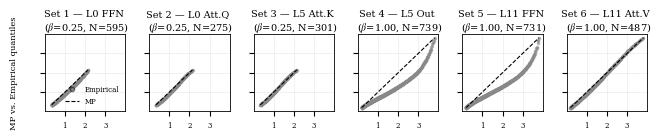

Done.


In [7]:
# --- Graph #5: QQ Plot Mosaic ---
# Model: BERT-base-uncased

import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =========================
# GLOBAL STYLE (Paper)
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 5,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "legend.fontsize": 5,
    "axes.linewidth": 0.6,
    "lines.linewidth": 1.2,
    "grid.linewidth": 0.4,
    "grid.alpha": 0.3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================
# Config
# =========================
WMP_DIR     = "bert_weights_WMP"
GRID_POINTS = 8192
COND_GRID   = 2000

# Sets 1-3: beta fixed at 0.25
# Sets 4-6: beta fixed at 1.00
SETTINGS = [
    dict(name="encoder.layer.0.intermediate.dense.weight_WMP",
         trim_kind="tw_or_fraction", c_tw=2.0, frac_sq=0.05, frac_rect=0.05,
         beta_override=0.25, label="Set 1 — L0 FFN"),
    dict(name="encoder.layer.0.attention.self.query.weight_WMP",
         trim_kind="tw_or_fraction", c_tw=2.0, frac_sq=0.05, frac_rect=0.05,
         beta_override=0.25, label="Set 2 — L0 Att.Q"),
    dict(name="encoder.layer.5.attention.self.key.weight_WMP",
         trim_kind="tw_or_fraction", c_tw=2.0, frac_sq=0.05, frac_rect=0.05,
         beta_override=0.25, label="Set 3 — L5 Att.K"),
    dict(name="encoder.layer.5.output.dense.weight_WMP",
         trim_kind="tw_or_fraction", c_tw=2.0, frac_sq=0.05, frac_rect=0.05,
         beta_override=1.00, label="Set 4 — L5 Out"),
    dict(name="encoder.layer.11.intermediate.dense.weight_WMP",
         trim_kind="tw_or_fraction", c_tw=2.0, frac_sq=0.05, frac_rect=0.05,
         beta_override=1.00, label="Set 5 — L11 FFN"),
    dict(name="encoder.layer.11.attention.self.value.weight_WMP",
         trim_kind="tw_or_fraction", c_tw=2.0, frac_sq=0.05, frac_rect=0.05,
         beta_override=1.00, label="Set 6 — L11 Att.V"),
]

# =========================
# Helpers
# =========================
def _load_matrix(p: Path):
    if p.suffix == ".npy":  return np.load(p)
    if p.suffix == ".npz":  return np.load(p)["data"]
    raise ValueError(f"Unsupported file type: {p.suffix}")

def _mp_support(beta: float):
    r = np.sqrt(beta); return (1 - r)**2, (1 + r)**2

def _mp_pdf(x, beta, a, b):
    x = np.asarray(x, dtype=np.float64)
    out = np.zeros_like(x)
    m = (x >= a) & (x <= b)
    xm = np.clip(x[m], 1e-15, None)
    out[m] = np.sqrt((b - xm) * (xm - a)) / (2 * np.pi * beta * xm)
    return out

def _cumtrapz_np(y, x):
    dx = np.diff(x); seg = 0.5 * (y[:-1] + y[1:]) * dx
    return np.concatenate([[0.0], np.cumsum(seg)])

def _mp_cdf(x, beta, grid_points=GRID_POINTS):
    a, b = _mp_support(beta)
    t = np.linspace(0.0, 1.0, grid_points)
    g = a + (b - a) * t * t
    pdf = _mp_pdf(g, beta, a, b)
    cdf_vals = _cumtrapz_np(pdf, g)
    cdf_vals /= cdf_vals[-1]
    return np.interp(x, g, cdf_vals, left=0.0, right=1.0)

def _edge_margin(beta, m, n, trim_kind, c_tw, frac_sq, frac_rect):
    a, b = _mp_support(beta); bandwidth = b - a
    n_eff = min(m, n); is_square = (m == n)
    tw = c_tw * (n_eff ** (-2/3)) * (1 + np.sqrt(beta))**(4/3)
    frac = (frac_sq if is_square else frac_rect) * bandwidth
    if trim_kind == "tw":             return tw
    if trim_kind == "fraction":       return frac
    if trim_kind == "tw_or_fraction": return max(tw, frac)
    raise ValueError("Invalid trim_kind")

def _find_manifest_entry(manifest, target):
    for e in manifest["files"]:
        if e.get("name","") == target: return e
    for e in manifest["files"]:
        if target in e.get("name","") or target in e.get("path",""): return e
    raise ValueError(f"Matrix '{target}' not found in manifest")

def compute_trimmed(W, TRIM_KIND, C_TW, EDGE_FRAC_SQUARE, EDGE_FRAC_RECT, beta_override=None):
    m, n = W.shape
    beta = beta_override if beta_override is not None else min(m, n) / max(m, n)
    s = np.linalg.svd(W, full_matrices=False, compute_uv=False)
    lambdas = (s**2) / max(m, n); lambdas.sort()
    a, b = _mp_support(beta)
    delta = _edge_margin(beta, m, n, TRIM_KIND, C_TW, EDGE_FRAC_SQUARE, EDGE_FRAC_RECT)
    L, U = a + delta, b - delta
    if L >= U: L, U = a, b
    mask = (lambdas >= L) & (lambdas <= U)
    lam_trim = lambdas[mask]; N_trim = lam_trim.size
    FL, FU = _mp_cdf([L, U], beta); den = max(FU - FL, 1e-12)
    mp_cdf_cond = lambda x: np.clip((_mp_cdf(x, beta) - FL) / den, 0, 1)
    return lam_trim, (a, b, L, U, beta), mp_cdf_cond, N_trim

# =========================
# Load manifest
# =========================
manifest = json.load(open(Path(WMP_DIR) / "manifest.json"))

# =========================
# MOSAIC: QQ Plots — 1x6 grid
# =========================
print("Building mosaic figure...")

fig, axes = plt.subplots(1, 6, figsize=(7, 1), sharex=True, sharey=True)
axes = axes.flatten()

for i, (ax, cfg) in enumerate(zip(axes, SETTINGS)):
    print(f"  [{i+1}/6] {cfg['label']}")

    entry = _find_manifest_entry(manifest, cfg["name"])
    W = _load_matrix(Path(WMP_DIR) / entry["path"]).astype(np.float64, copy=False)
    print(f"         shape=({W.shape[0]:.2e} x {W.shape[1]:.2e}), dtype={W.dtype}")

    lam_trim, (a, b, L, U, beta), mp_cdf_cond, N_trim = compute_trimmed(
        W, cfg["trim_kind"], cfg["c_tw"], cfg["frac_sq"], cfg["frac_rect"],
        beta_override=cfg.get("beta_override", None)
    )
    print(f"         beta={beta:.4e} | support=[{a:.4e}, {b:.4e}]")
    print(f"         trim=[{L:.4e}, {U:.4e}] | N_trim={N_trim:.2e}")

    emp_q  = np.sort(lam_trim)
    q_grid = np.linspace(0, 1, N_trim)
    xs     = np.linspace(L, U, COND_GRID)
    mp_q   = np.interp(q_grid, mp_cdf_cond(xs), xs)

    ax.plot(mp_q, emp_q, "o", ms=1.5, alpha=0.5, color="#888888")
    ax.plot([mp_q.min(), mp_q.max()], [mp_q.min(), mp_q.max()],
            color="black", linestyle="--", linewidth=0.8)

    ax.set_title(f"{cfg['label']} \n ($\\beta$={beta:.2f}, N={N_trim})", pad=2)
    ax.grid(True)

    if i != 0:
        ax.yaxis.set_ticklabels([])

# Single legend on the first axes only
handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#888888",
           markersize=3, alpha=0.5, label="Empirical"),
    Line2D([0], [0], color="black", linewidth=0.8, linestyle="--", label="MP"),
]
axes[0].legend(handles=handles, loc="lower right", frameon=False)

fig.text(-0.01, 0.5, "MP vs. Empirical quantiles", va="center",
         rotation="vertical", fontsize=6)

plt.subplots_adjust(left=0.04, hspace=0.0, wspace=0.3)

# --- Save PDF (paper) ---
pdf_path = "graph_core_diag_05_bert_base.pdf"
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
print(f"PDF saved: {pdf_path}")

# --- Display figure ---
plt.show()

plt.close()
print("Done.")

# Graph 6 - Layer vs. matrix-type heatmaps of KS test outcomes under varying α thresholds

Building mosaic figure...
  [1/6] Set 1 — $\alpha$=0.01
  [2/6] Set 2 — $\alpha$=0.05
  [3/6] Set 3 — $\alpha$=0.10
  [4/6] Set 4 — $\alpha$=0.20
  [5/6] Set 5 — $\alpha$=0.05
  [6/6] Set 6 — $\alpha$=0.05
PDF saved: graph_level_views_01_bert_base.pdf


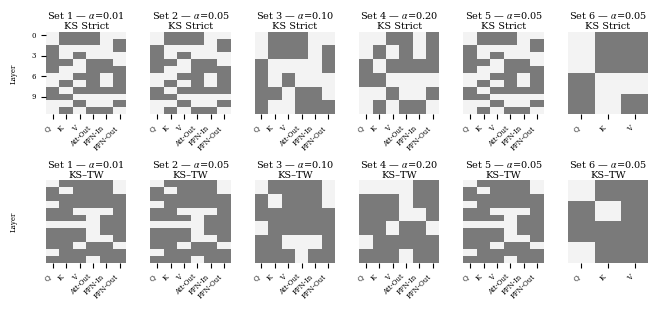

Done.


In [8]:
# ============================================================
# Graph 6 — Layer vs. matrix-type KS heatmaps
# ============================================================

import seaborn as sns

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 5,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "legend.fontsize": 5,
    "axes.linewidth": 0.6,
    "lines.linewidth": 1.2,
    "grid.linewidth": 0.4,
    "grid.alpha": 0.3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

GRAY_CMAP  = "Greys"
VMIN, VMAX = 0.1, 0.6

def plot_ks_mosaic_separate(decisions_strict, decisions_tw,
                             savepath="graph_level_views_01_bert_base.pdf"):
    # BERT-base: 12 layers, 6 matrix types
    param_sets = [
        dict(alpha=0.01, layers=list(range(12)),
             mat_types=["Q","K","V","Att-Out","FFN-In","FFN-Out"],
             title="Set 1 — $\\alpha$=0.01"),
        dict(alpha=0.05, layers=list(range(12)),
             mat_types=["Q","K","V","Att-Out","FFN-In","FFN-Out"],
             title="Set 2 — $\\alpha$=0.05"),
        dict(alpha=0.10, layers=list(range(6)),
             mat_types=["Q","K","V","Att-Out","FFN-In","FFN-Out"],
             title="Set 3 — $\\alpha$=0.10"),
        dict(alpha=0.20, layers=list(range(6, 12)),
             mat_types=["Q","K","V","Att-Out","FFN-In","FFN-Out"],
             title="Set 4 — $\\alpha$=0.20"),
        dict(alpha=0.05, layers=list(range(12)),
             mat_types=["Q","K","V","Att-Out","FFN-In","FFN-Out"],
             title="Set 5 — $\\alpha$=0.05"),
        dict(alpha=0.05, layers=list(range(4)),
             mat_types=["Q","K","V"],
             title="Set 6 — $\\alpha$=0.05"),
    ]

    print("Building mosaic figure...")
    fig, axes = plt.subplots(2, 6, figsize=(7, 3))

    for idx, params in enumerate(param_sets):
        print(f"  [{idx+1}/6] {params['title']}")

        alpha = params["alpha"]
        L     = params["layers"]
        M     = params["mat_types"]
        title = params["title"]

        d_strict = decisions_strict[np.ix_(L, range(min(len(M), decisions_strict.shape[1])))]
        d_tw     = decisions_tw[np.ix_(L,     range(min(len(M), decisions_tw.shape[1])))]

        d_strict_gs = np.where(d_strict == 0, VMIN, VMAX)
        d_tw_gs     = np.where(d_tw     == 0, VMIN, VMAX)

        ax_strict = axes[0, idx]
        ax_tw     = axes[1, idx]

        # KS Strict (row 0)
        sns.heatmap(d_strict_gs, cmap=GRAY_CMAP, vmin=0, vmax=1,
                    cbar=False, annot=False,
                    xticklabels=M, yticklabels=L, ax=ax_strict)
        ax_strict.set_title(f"{title}\nKS Strict", pad=2)
        ax_strict.set_xticklabels(ax_strict.get_xticklabels(), rotation=45, ha="right")

        yticks      = [t for t in ax_strict.get_yticks() if int(t) % 3 == 0]
        yticklabels = [str(L[int(t)]) for t in yticks if int(t) < len(L)]
        ax_strict.set_yticks(yticks)
        ax_strict.set_yticklabels(yticklabels, rotation=0)

        if idx == 0:
            ax_strict.set_ylabel("Layer")
            ax_strict.yaxis.set_label_coords(-0.35, 0.5)
        else:
            ax_strict.set_ylabel("")
            ax_strict.yaxis.set_visible(False)

        # KS-TW (row 1)
        sns.heatmap(d_tw_gs, cmap=GRAY_CMAP, vmin=0, vmax=1,
                    cbar=False, annot=False,
                    xticklabels=M, yticklabels=False, ax=ax_tw)
        ax_tw.set_title(f"{title}\nKS–TW", pad=2)
        ax_tw.set_xticklabels(ax_tw.get_xticklabels(), rotation=45, ha="right")

        if idx == 0:
            ax_tw.set_ylabel("Layer")
            ax_tw.yaxis.set_label_coords(-0.35, 0.5)
        else:
            ax_tw.set_ylabel("")
            ax_tw.yaxis.set_visible(False)

    handles = [
        Patch(facecolor=plt.cm.Greys(VMIN), label="Accept"),
        Patch(facecolor=plt.cm.Greys(VMAX), label="Reject"),
    ]
    #fig.legend(handles=handles, loc="lower center", ncol=2,
               #frameon=False, bbox_to_anchor=(0.5, -0.02))

    plt.subplots_adjust(left=0.04, hspace=0.8, wspace=0.3)

    pdf_path = savepath
    plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
    print(f"PDF saved: {pdf_path}")
    plt.show()
    plt.close()
    print("Done.")


np.random.seed(42)
decisions_strict = np.random.choice([0, 1], size=(12, 6), p=[0.4, 0.6])
decisions_tw     = np.random.choice([0, 1], size=(12, 6), p=[0.3, 0.7])

plot_ks_mosaic_separate(decisions_strict, decisions_tw,
                        savepath="graph_level_views_01_bert_base.pdf")

# Graph 7 - Per-layer acceptance rates under KS-strict and KS–TW criteria

Building mosaic figure...
  [1/6] Baseline
  [2/6] Strict dominance
  [3/6] Low $\alpha$ effect
  [4/6] Square vs rect
  [5/6] Edge-sensitive
  [6/6] Extreme disag.
PDF saved: graph_level_views_02_bert_base.pdf


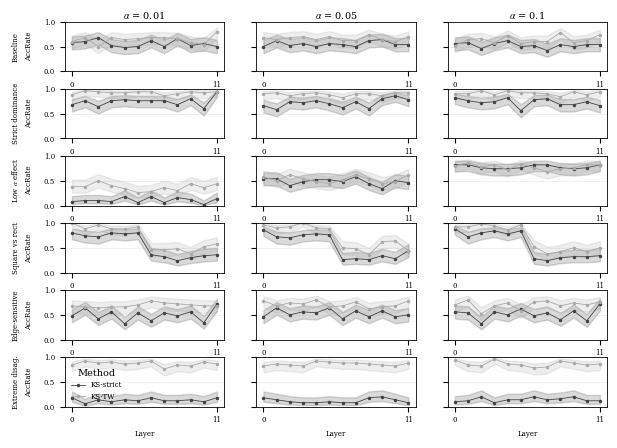

Done.


In [9]:
# ============================================================
# Graph 7 — Per-layer acceptance rates (lines with CIs)
# ============================================================

from statsmodels.stats.proportion import proportion_confint

METHOD_COLORS = ["#444444", "#aaaaaa"]

# BERT-base: 12 layers
layers  = np.arange(12)
alphas  = [0.01, 0.05, 0.10]
methods = ["KS-strict", "KS-TW"]
n_boot  = 50
rng     = np.random.default_rng(42)

def scenario_baseline(layer, method, alpha):
    return 0.55 if method == "KS-strict" else 0.65

def scenario_strict_dominance(layer, method, alpha):
    return 0.75 if method == "KS-strict" else 0.90

def scenario_low_alpha(layer, method, alpha):
    if alpha == 0.01:
        return 0.15 if method == "KS-strict" else 0.35
    elif alpha == 0.05:
        return 0.45 if method == "KS-strict" else 0.55
    else:
        return 0.75 if method == "KS-strict" else 0.80

def scenario_square_vs_rect(layer, method, alpha):
    # Split at halfway: layers 0-5 (square) vs 6-11 (rect)
    if layer < 6:
        return 0.80 if method == "KS-strict" else 0.90
    else:
        return 0.30 if method == "KS-strict" else 0.50

def scenario_edge_sensitive(layer, method, alpha):
    if method == "KS-strict":
        return 0.40 + 0.20 * (layer % 2)
    else:
        return 0.70

def scenario_extreme_disagreement(layer, method, alpha):
    return 0.12 if method == "KS-strict" else 0.87

SCENARIOS = {
    "Baseline":              scenario_baseline,
    "Strict dominance":      scenario_strict_dominance,
    "Low $\\alpha$ effect":  scenario_low_alpha,
    "Square vs rect":        scenario_square_vs_rect,
    "Edge-sensitive":        scenario_edge_sensitive,
    "Extreme disag.":        scenario_extreme_disagreement,
}

print("Building mosaic figure...")

fig, axes = plt.subplots(len(SCENARIOS), len(alphas),
                         figsize=(7, 5), sharey=True)
axes = np.array(axes)

x        = np.arange(len(layers))
last_row = len(SCENARIOS) - 1
last_lay = len(layers) - 1

for row, (name, func) in enumerate(SCENARIOS.items()):
    print(f"  [{row+1}/6] {name}")

    decisions = np.zeros((len(layers), len(methods), len(alphas), n_boot))
    for i, layer in enumerate(layers):
        for j, method in enumerate(methods):
            for k, alpha in enumerate(alphas):
                p = func(layer, methods[j], alphas[k])
                decisions[i,j,k,:] = rng.choice([0,1], size=n_boot, p=[1-p, p])

    accept_means = np.mean(decisions, axis=-1)
    ci_low  = np.zeros_like(accept_means)
    ci_high = np.zeros_like(accept_means)

    for i in range(len(layers)):
        for j in range(len(methods)):
            for k in range(len(alphas)):
                count = np.sum(decisions[i,j,k,:])
                low, high = proportion_confint(count, n_boot, alpha=0.05, method="wilson")
                ci_low[i,j,k]  = low
                ci_high[i,j,k] = high

    for k, alpha in enumerate(alphas):
        ax = axes[row, k]

        for j, method in enumerate(methods):
            ax.plot(x, accept_means[:,j,k],
                    marker="o", ms=1.5, linewidth=0.6,
                    color=METHOD_COLORS[j],
                    label=method if (row == last_row and k == 0) else None)
            ax.fill_between(x, ci_low[:,j,k], ci_high[:,j,k],
                            alpha=0.2, color=METHOD_COLORS[j])

        if row == 0:
            ax.set_title(f"$\\alpha$ = {alpha}", pad=2)

        if row == last_row:
            ax.set_xlabel("Layer")

        ax.set_xticks([0, last_lay])
        ax.set_xticklabels([str(layers[0]), str(layers[last_lay])])

        ax.set_ylim(0, 1)
        ax.grid(True, axis="y")

        if k == 0:
            ax.set_ylabel("AccRate")
            ax.yaxis.set_label_coords(-0.20, 0.5)
            ax.text(-0.28, 0.5, name, va="center", ha="right",
                    rotation=90, transform=ax.transAxes, fontsize=5)
        else:
            ax.set_ylabel("")

axes[last_row, 0].legend(title="Method", frameon=False)
plt.subplots_adjust(hspace=0.35, wspace=0.2)

pdf_path = "graph_level_views_02_bert_base.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
print(f"PDF saved: {pdf_path}")
plt.show()
plt.close()
print("Done.")

# Graph 8 - Aspect ratio β versus KS statistic (Dp) across simulation scenarios

Building mosaic figure...
  [1/6] Baseline balanced
  [2/6] Strict dominance
  [3/6] Edge-sensitive
  [4/6] Low $\alpha$ test
  [5/6] Smooth trimming
  [6/6] Mixed block structure
PDF saved: graph_level_views_03_bert_base.pdf


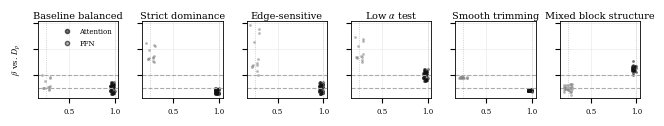

Done.


In [10]:
# ============================================================
# Graph 8 — β vs KS statistic scatter
# ============================================================

FAMILY_COLORS = {"FFN": "#888888", "Attention": "#111111"}

def generate_data_scenario(scenario, n_points=50):
    np.random.seed(42)
    betas, ks_vals, fams = [], [], []

    if scenario == "baseline":
        for _ in range(n_points):
            if np.random.rand() < 0.67:
                beta = np.random.uniform(0.95, 1.0); fam = "Attention"
                ks   = np.random.uniform(0.05, 0.15)
            else:
                beta = np.random.uniform(0.20, 0.30); fam = "FFN"
                ks   = np.random.uniform(0.08, 0.20)
            betas.append(beta); ks_vals.append(ks); fams.append(fam)

    elif scenario == "strict":
        for _ in range(n_points):
            if np.random.rand() < 0.67:
                beta = np.random.uniform(0.95, 1.0); fam = "Attention"
                ks   = np.random.uniform(0.05, 0.10)
            else:
                beta = np.random.uniform(0.20, 0.30); fam = "FFN"
                ks   = np.random.uniform(0.30, 0.45)
            betas.append(beta); ks_vals.append(ks); fams.append(fam)

    elif scenario == "edge":
        for _ in range(n_points):
            if np.random.rand() < 0.67:
                beta = np.random.uniform(0.95, 1.0); fam = "Attention"
                ks   = np.random.uniform(0.05, 0.15)
            else:
                beta = np.random.uniform(0.20, 0.30); fam = "FFN"
                ks   = np.random.uniform(0.20, 0.60)
            betas.append(beta); ks_vals.append(ks); fams.append(fam)

    elif scenario == "lowalpha":
        for _ in range(n_points):
            if np.random.rand() < 0.67:
                beta = np.random.uniform(0.95, 1.0); fam = "Attention"
                ks   = np.random.uniform(0.15, 0.25)
            else:
                beta = np.random.uniform(0.20, 0.30); fam = "FFN"
                ks   = np.random.uniform(0.30, 0.50)
            betas.append(beta); ks_vals.append(ks); fams.append(fam)

    elif scenario == "smooth":
        for _ in range(n_points):
            if np.random.rand() < 0.67:
                beta = np.random.uniform(0.95, 1.0); fam = "Attention"
                ks   = np.random.normal(0.08, 0.005)
            else:
                beta = np.random.uniform(0.20, 0.30); fam = "FFN"
                ks   = np.random.normal(0.18, 0.005)
            betas.append(beta); ks_vals.append(ks); fams.append(fam)

    elif scenario == "mixed":
        for i in range(n_points):
            if i < n_points // 2:
                beta = np.random.uniform(0.95, 1.0)
                ks   = np.random.normal(0.25, 0.02); fam = "Attention"
            else:
                beta = np.random.uniform(0.20, 0.30)
                ks   = np.random.normal(0.10, 0.02); fam = "FFN"
            betas.append(beta); ks_vals.append(ks); fams.append(fam)

    return np.array(betas), np.array(ks_vals), np.array(fams)

scenarios = {
    "baseline": "Baseline balanced",
    "strict":   "Strict dominance",
    "edge":     "Edge-sensitive",
    "lowalpha": "Low $\\alpha$ test",
    "smooth":   "Smooth trimming",
    "mixed":    "Mixed block structure",
}

print("Building mosaic figure...")

fig, axes = plt.subplots(1, 6, figsize=(7, 1), sharex=True, sharey=True)
axes = axes.flatten()

for i, (ax, (key, title)) in enumerate(zip(axes, scenarios.items())):
    print(f"  [{i+1}/6] {title}")

    betas, ks_vals, fams = generate_data_scenario(key, n_points=60)

    for fam in np.unique(fams):
        idx = fams == fam
        ax.scatter(betas[idx], ks_vals[idx],
                   alpha=0.6, s=4, color=FAMILY_COLORS[fam],
                   linewidths=0)

    ax.axvline(1.0,  color="#aaaaaa", ls=":", linewidth=0.6, alpha=0.5)
    ax.axvline(0.25, color="#888888", ls=":", linewidth=0.6, alpha=0.5)
    ax.axhline(0.1,  color="#aaaaaa", ls="--", linewidth=0.8)
    ax.axhline(0.2,  color="#aaaaaa", ls="--", linewidth=0.8)

    ax.set_title(f"{title}", pad=2)
    ax.grid(True)

    if i != 0:
        ax.yaxis.set_ticklabels([])

handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#111111",
           markersize=3, alpha=0.6, label="Attention"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#888888",
           markersize=3, alpha=0.6, label="FFN"),
]
axes[0].legend(handles=handles, loc="upper right", frameon=False)
fig.text(0.0, 0.5, r"$\beta$ vs. $D_{p}$", va="center",
         rotation="vertical", fontsize=6)
plt.subplots_adjust(left=0.04, hspace=0.0, wspace=0.3)

pdf_path = "graph_level_views_03_bert_base.pdf"
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
print(f"PDF saved: {pdf_path}")
plt.show()
plt.close()
print("Done.")

# Graph 9 - Bootstrap p-value distributions across calibration scenarios

Building mosaic figure...
  [1/6] Null calibration
  [2/6] Anti-cons. strict
  [3/6] Conservative TW
  [4/6] Both anti-cons.
  [5/6] Skewed strict
  [6/6] Mixed calibration
PDF saved: graph_shrinkage_control_01_bert_base.pdf


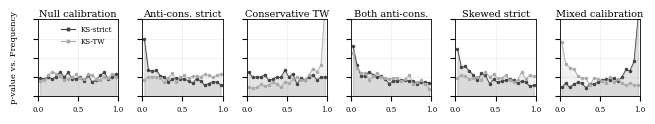

Done.


In [11]:
# ============================================================
# Graph 9 — Bootstrap p-value distributions
# ============================================================

METHOD_COLORS = {"KS-strict": "#444444", "KS-TW": "#aaaaaa"}

n_boot = 1000

def simulate_pvalues(null=True, skew=0.0, conservative=False, seed=None):
    rng = np.random.default_rng(seed)
    if null:
        pvals = rng.random(n_boot)
    else:
        pvals = rng.beta(0.7, 1.0, size=n_boot)
    if skew > 0:
        pvals = np.power(pvals, 1 + skew)
    if conservative:
        pvals = 1 - np.power(1 - pvals, 2)
    return np.clip(pvals, 0, 1)

SCENARIOS_P = {
    "Null calibration":  (simulate_pvalues(null=True,  seed=1),
                          simulate_pvalues(null=True,  seed=2)),
    "Anti-cons. strict": (simulate_pvalues(null=False, seed=3),
                          simulate_pvalues(null=True,  seed=4)),
    "Conservative TW":   (simulate_pvalues(null=True,  seed=5),
                          simulate_pvalues(null=True,  conservative=True, seed=6)),
    "Both anti-cons.":   (simulate_pvalues(null=False, seed=7),
                          simulate_pvalues(null=False, seed=8)),
    "Skewed strict":     (simulate_pvalues(null=True,  skew=0.5, seed=9),
                          simulate_pvalues(null=True,  seed=10)),
    "Mixed calibration": (simulate_pvalues(null=True,  conservative=True, seed=11),
                          simulate_pvalues(null=False, seed=12)),
}

print("Building mosaic figure...")

fig, axes = plt.subplots(1, 6, figsize=(7, 1), sharex=True, sharey=True)
axes = axes.flatten()

bins    = np.linspace(0, 1, 21)
centers = 0.5 * (bins[:-1] + bins[1:])

for i, (ax, (title, (pvals_strict, pvals_tw))) in enumerate(zip(axes, SCENARIOS_P.items())):
    print(f"  [{i+1}/6] {title}")

    for pvals, label in [
        (pvals_strict, "KS-strict"),
        (pvals_tw,     "KS-TW"),
    ]:
        color = METHOD_COLORS[label]
        counts, _ = np.histogram(pvals, bins=bins)
        ax.plot(centers, counts, marker="o", ms=1.5, linewidth=0.6, color=color)
        ax.fill_between(centers, counts, alpha=0.15, color=color)

    ax.set_title(title, pad=2)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, n_boot // 5)
    ax.grid(True)

    if i != 0:
        ax.yaxis.set_ticklabels([])

handles = [
    Line2D([0], [0], color="#444444", linewidth=0.8, marker="o",
           markersize=2, label="KS-strict"),
    Line2D([0], [0], color="#aaaaaa", linewidth=0.8, marker="o",
           markersize=2, label="KS-TW"),
]
axes[0].legend(handles=handles, loc="upper right", frameon=False)
fig.text(0.0, 0.5, "p-value vs. Frequency", va="center",
         rotation="vertical", fontsize=6)
plt.subplots_adjust(left=0.04, hspace=0.0, wspace=0.3)

pdf_path = "graph_shrinkage_control_01_bert_base.pdf"
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
print(f"PDF saved: {pdf_path}")
plt.show()
plt.close()
print("Done.")

# Graph 10 - Sensitivity of KS–TWd outcomes to edge relaxation parameter cα

Building mosaic figure...
  [1/6] Stable accept.
  [2/6] Strict→Relax accept.
  [3/6] Persistent rejection
  [4/6] Mixed families
  [5/6] Edge-sensitive
  [6/6] $\alpha$-dependent
PDF saved: graph_shrinkage_control_02_bert_base.pdf


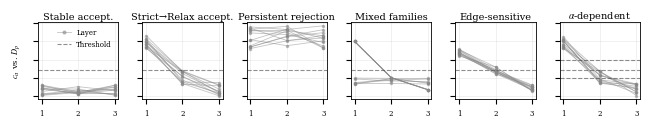

Done.


In [12]:
# ============================================================
# Graph 10 — Sensitivity of KS–TW to edge relaxation
# ============================================================

np.random.seed(42)
layers_g10  = list(range(12))
c_TW_values = [1, 2, 3]
thresholds  = [0.10, 0.12, 0.15]

def scenario_stable_accept(layer, c):
    return np.random.uniform(0.05, 0.08)

def scenario_relax_accept(layer, c):
    return 0.20 / c + np.random.uniform(-0.02, 0.02)

def scenario_persistent_reject(layer, c):
    return np.random.uniform(0.18, 0.25)

def scenario_mixed_g10(layer, c):
    # Split at halfway: layers 0-5 (square) vs 6-11 (rect)
    if layer < 6:
        return 0.20 / c
    else:
        return np.random.uniform(0.08, 0.10)

def scenario_edgesensitive(layer, c):
    return 0.12 + 0.05 * np.sin(0.5 * np.pi * c) \
                + np.random.uniform(-0.01, 0.01)

def scenario_alpha_dependent(layer, c):
    return 0.20 / c + np.random.uniform(-0.02, 0.02)

SCENARIOS_G10 = [
    ("Stable accept.",           scenario_stable_accept),
    ("Strict→Relax accept.",     scenario_relax_accept),
    ("Persistent rejection",     scenario_persistent_reject),
    ("Mixed families",           scenario_mixed_g10),
    ("Edge-sensitive",           scenario_edgesensitive),
    ("$\\alpha$-dependent",      scenario_alpha_dependent),
]

print("Building mosaic figure...")

fig, axes = plt.subplots(1, 6, figsize=(7, 1), sharex=True, sharey=True)
axes = axes.flatten()

for i, (ax, (title, func)) in enumerate(zip(axes, SCENARIOS_G10)):
    print(f"  [{i+1}/6] {title}")

    D_trim = np.zeros((len(layers_g10), len(c_TW_values)))
    for j, c in enumerate(c_TW_values):
        for layer in range(len(layers_g10)):
            D_trim[layer, j] = func(layer, c)

    for layer in range(len(layers_g10)):
        ax.plot(c_TW_values, D_trim[layer, :],
                marker="o", ms=1.5, alpha=0.5, linewidth=0.6,
                color="#888888")

    if title == "$\\alpha$-dependent":
        for th in thresholds:
            ax.axhline(th, linestyle="--", color="#444444",
                       linewidth=0.8, alpha=0.6)
    else:
        ax.axhline(0.12, linestyle="--", color="#444444",
                   linewidth=0.8, alpha=0.6)

    ax.set_title(title, pad=2)
    ax.set_xticks(c_TW_values)
    ax.grid(True)

    if i != 0:
        ax.yaxis.set_ticklabels([])

handles = [
    Line2D([0], [0], color="#888888", linewidth=0.6, marker="o",
           markersize=2, alpha=0.5, label="Layer"),
    Line2D([0], [0], color="#444444", linewidth=0.8, linestyle="--",
           alpha=0.6, label="Threshold"),
]
axes[0].legend(handles=handles, loc="upper right", frameon=False)
fig.text(0, 0.5, r"$c_{\alpha}$ vs. $D_{p}$", va="center",
         rotation="vertical", fontsize=6)
plt.subplots_adjust(left=0.04, hspace=0.0, wspace=0.3)

pdf_path = "graph_shrinkage_control_02_bert_base.pdf"
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
print(f"PDF saved: {pdf_path}")
plt.show()
plt.close()
print("Done.")

# Graph 11 - Type-I calibration curves on synthetic MPd-null matrices.

Building mosaic figure...
  [1/4] 768x768
  [2/4] 3072x768
  [3/4] 768x3072
  [4/4] 768x768_2
PDF saved: graph_shrinkage_control_03_bert_base.pdf


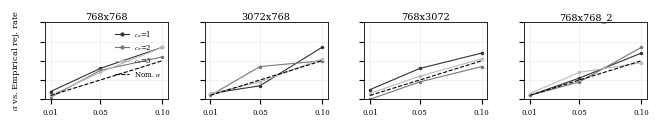

Done.


In [13]:
# --- Graph #11: Type-I calibration curves (synthetic MP) ---
# Model: BERT-base-uncased

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =========================
# GLOBAL STYLE (Paper)
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 5,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "legend.fontsize": 5,
    "axes.linewidth": 0.6,
    "lines.linewidth": 1.2,
    "grid.linewidth": 0.4,
    "grid.alpha": 0.3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

C_TW_COLORS = {1: "#333333", 2: "#777777", 3: "#bbbbbb"}

# =========================
# Config
# =========================
np.random.seed(42)
n_boot      = 200
alphas      = [0.01, 0.05, 0.10]
c_TW_values = [1, 2, 3]

# BERT-base real matrix shapes:
#   Q/K/V/Att-Out : 768×768  (β=1.0,  square)
#   FFN-In        : 3072×768 (β=0.25, rect)
#   FFN-Out       : 768×3072 (β=0.25, rect)
#   Att-Out       : 768×768  (β=1.0,  square) — second square family
shapes = [
    (768,  768),   # Q / K / V / Att-Out  (square, β=1.0)
    (3072, 768),   # FFN-In               (rect,   β=0.25)
    (768,  3072),  # FFN-Out              (rect,   β=0.25)
    (768,  768),   # Pooler / output      (square, β=1.0)
]

# =========================
# Mock KS-TW rejection test
# =========================
def ks_tw_test_null(m, n, alpha, c_tw):
    bias = 0.01 * (1.0 / c_tw) + 0.005 * (m == n)
    return np.random.rand() < (alpha + bias)

# =========================
# Simulate rejection rates
# =========================
print("Building mosaic figure...")

results = {}
for (m, n) in shapes:
    shape_name = f"{m}x{n}"
    # Deduplicate keys for repeated shapes (e.g. two 768x768 entries)
    key = shape_name
    suffix = 1
    while key in results:
        suffix += 1
        key = f"{shape_name}_{suffix}"
    results[key] = {}
    for c in c_TW_values:
        rejections = []
        for alpha in alphas:
            count = sum(ks_tw_test_null(m, n, alpha, c) for _ in range(n_boot))
            rejections.append(count / n_boot)
        results[key][c] = rejections

# =========================
# MOSAIC: 1x4 grid
# =========================
fig, axes = plt.subplots(1, 4, figsize=(7, 1), sharey=True)
axes = axes.flatten()

for i, (ax, (shape_name, data)) in enumerate(zip(axes, results.items())):
    print(f"  [{i+1}/4] {shape_name}")

    for c in c_TW_values:
        ax.plot(alphas, data[c], marker="o", ms=1.5, linewidth=0.8,
                color=C_TW_COLORS[c])

    ax.plot(alphas, alphas, color="black", linestyle="--", linewidth=0.8)

    ax.set_title(shape_name, pad=2)
    ax.set_ylim(0, 0.2)
    ax.set_xticks(alphas)
    ax.grid(True)

    if i != 0:
        ax.yaxis.set_ticklabels([])

# Single legend on first axes only
handles = [
    Line2D([0], [0], color=C_TW_COLORS[c], linewidth=0.8, marker="o",
           markersize=2, label=f"$c_{{\\alpha}}$={c}")
    for c in c_TW_values
] + [
    Line2D([0], [0], color="black", linewidth=0.8, linestyle="--",
           label="Nom. $\\alpha$"),
]
axes[0].legend(handles=handles, frameon=False)

fig.text(-0.01, 0.5, r"$\alpha$ vs. Empirical rej. rate", va="center",
         rotation="vertical", fontsize=6)

plt.subplots_adjust(left=0.04, hspace=0.0, wspace=0.3)

# --- Save PDF (paper) ---
pdf_path = "graph_shrinkage_control_03_bert_base.pdf"
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
print(f"PDF saved: {pdf_path}")

# --- Display figure ---
plt.show()
plt.close()
print("Done.")

# Graph 12 - Bootstrap reference envelopes for empirical CDFs under different distributional scenarios.

Building mosaic figure...
  [1/6] Baseline ($\chi^2$ null)
  [2/6] Shifted mean
  [3/6] Heavy-tailed ($t_3$)
  [4/6] Compressed variance
  [5/6] Mixture (0 & 2)
  [6/6] Small $n=50$
PDF saved: graph_shrinkage_control_04_bert_base.pdf


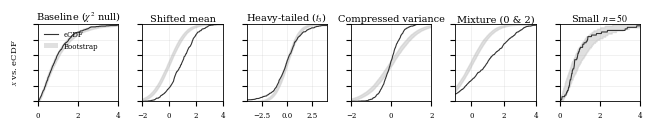

Done.


In [14]:
# ============================================================
# Graph 12 — eCDF vs bootstrap bands
# ============================================================

np.random.seed(42)

def ecdf(x, grid):
    return np.searchsorted(np.sort(x), grid, side="right") / len(x)

def generate_data(kind, n):
    if kind == "normal":
        return np.random.normal(size=n)
    elif kind == "shifted":
        return np.random.normal(loc=1.0, scale=1.0, size=n)
    elif kind == "t3":
        return np.random.standard_t(df=3, size=n)
    elif kind == "compressed":
        return np.random.normal(loc=0.0, scale=0.5, size=n)
    elif kind == "mixture":
        return np.concatenate([
            np.random.normal(loc=0.0, scale=1.0, size=n//2),
            np.random.normal(loc=2.0, scale=1.0, size=n//2)
        ])
    else:  # chisquare
        return np.random.chisquare(df=3, size=n) / 3.0

scenarios_g12 = [
    ("chisq",      "chisq",  500, "Baseline ($\\chi^2$ null)", (0,  4)),
    ("shifted",    "normal", 500, "Shifted mean",              (-2, 4)),
    ("t3",         "normal", 500, "Heavy-tailed ($t_3$)",      (-4, 4)),
    ("compressed", "normal", 500, "Compressed variance",       (-2, 2)),
    ("mixture",    "normal", 500, "Mixture (0 & 2)",           (-1, 4)),
    ("chisq",      "chisq",   50, "Small $n=50$",              (0,  4)),
]

print("Building mosaic figure...")

fig, axes = plt.subplots(1, 6, figsize=(7, 1), sharex=False, sharey=True)
axes = axes.flatten()

for i, (ax, (obs_kind, boot_kind, n, title, (L, U))) in enumerate(
        zip(axes, scenarios_g12)):
    print(f"  [{i+1}/6] {title}")

    observed   = generate_data(obs_kind, n)
    grid       = np.linspace(L, U, 300)
    obs_ecdf   = ecdf(observed, grid)
    boot_ecdfs = np.array([ecdf(generate_data(boot_kind, n), grid)
                           for _ in range(300)])
    lower = np.percentile(boot_ecdfs, 5,  axis=0)
    upper = np.percentile(boot_ecdfs, 95, axis=0)

    ax.fill_between(grid, lower, upper, color="#cccccc", alpha=0.6)
    ax.plot(grid, obs_ecdf, color="#333333", linewidth=0.8)

    ax.set_xlim(L, U)
    ax.set_ylim(0, 1)
    ax.set_title(title, pad=2)
    ax.grid(True)

    if i != 0:
        ax.yaxis.set_ticklabels([])

handles = [
    Line2D([0], [0], color="#333333", linewidth=0.8, label="eCDF"),
    Patch(facecolor="#cccccc", alpha=0.6, label="Bootstrap"),
]
axes[0].legend(handles=handles, loc="upper left", frameon=False)
fig.text(0, 0.5, "$x$ vs. eCDF", va="center",
         rotation="vertical", fontsize=6)
plt.subplots_adjust(left=0.04, hspace=0.0, wspace=0.3)

pdf_path = "graph_shrinkage_control_04_bert_base.pdf"
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
print(f"PDF saved: {pdf_path}")
plt.show()
plt.close()
print("Done.")